In [1]:
import random
import time
import os

import numpy as np
import pandas as pd
from generate_recipe_task import *

import matplotlib.pyplot as plt

from together import Together

In [ ]:
recipe_df = pd.read_csv("csv/full_dataset.csv", index_col=0)
recipe_df.head()

In [3]:
num_ings = [len(eval(row.loc['NER'])) for i, row in recipe_df.iterrows()]
num_steps = [len(eval(row.loc['directions'])) for i, row in recipe_df.iterrows()]
recipe_df['num_steps'] = num_steps
recipe_df['num_ings'] = num_ings

In [4]:
bins = [0, 8, 16, 32, 64, 128]

stepwise_ings = {}
stepwise_steps = {}

for i in range(1, len(bins)):
    print(f'Current Bin: {bins[i]}')
    stepwise_steps[bins[i]] = recipe_df[bins[i] >= recipe_df['num_steps']][bins[i-1] < recipe_df['num_steps']]
    stepwise_ings[bins[i]] = recipe_df[bins[i] >= recipe_df['num_ings']][bins[i-1] < recipe_df['num_ings']]
    print(f'Recipes in ings bin: {len(stepwise_ings[bins[i]])}')
    print(f'Recipes in steps bin: {len(stepwise_steps[bins[i]])}')
    print()

Current Bin: 8


/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_34220/2277107203.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stepwise_steps[bins[i]] = recipe_df[bins[i] >= recipe_df['num_steps']][bins[i-1] < recipe_df['num_steps']]
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_34220/2277107203.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stepwise_ings[bins[i]] = recipe_df[bins[i] >= recipe_df['num_ings']][bins[i-1] < recipe_df['num_ings']]


Recipes in ings bin: 1270340
Recipes in steps bin: 1691175

Current Bin: 16


/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_34220/2277107203.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stepwise_steps[bins[i]] = recipe_df[bins[i] >= recipe_df['num_steps']][bins[i-1] < recipe_df['num_steps']]
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_34220/2277107203.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stepwise_ings[bins[i]] = recipe_df[bins[i] >= recipe_df['num_ings']][bins[i-1] < recipe_df['num_ings']]


Recipes in ings bin: 875576
Recipes in steps bin: 430290

Current Bin: 32


/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_34220/2277107203.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stepwise_steps[bins[i]] = recipe_df[bins[i] >= recipe_df['num_steps']][bins[i-1] < recipe_df['num_steps']]
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_34220/2277107203.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stepwise_ings[bins[i]] = recipe_df[bins[i] >= recipe_df['num_ings']][bins[i-1] < recipe_df['num_ings']]
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_34220/2277107203.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stepwise_steps[bins[i]] = recipe_df[bins[i] >= recipe_df['num_steps']][bins[i-1] < recipe_df['num_steps']]


Recipes in ings bin: 83424
Recipes in steps bin: 100057

Current Bin: 64


/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_34220/2277107203.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stepwise_ings[bins[i]] = recipe_df[bins[i] >= recipe_df['num_ings']][bins[i-1] < recipe_df['num_ings']]
/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_34220/2277107203.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stepwise_steps[bins[i]] = recipe_df[bins[i] >= recipe_df['num_steps']][bins[i-1] < recipe_df['num_steps']]


Recipes in ings bin: 1213
Recipes in steps bin: 9273

Current Bin: 128
Recipes in ings bin: 12
Recipes in steps bin: 333



/var/folders/ls/1q5638vj1r30mlyshpjzg5zw0000gp/T/ipykernel_34220/2277107203.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  stepwise_ings[bins[i]] = recipe_df[bins[i] >= recipe_df['num_ings']][bins[i-1] < recipe_df['num_ings']]


In [5]:
stepwise_ings[8].sample(10).head()

,title,ingredients,directions,link,source,NER,num_steps,num_ings
833322,Twice Baked Potatoes,"[""2 eggs"", ""4 Tbsp. butter"", ""4 Tbsp. whipping...","[""Bake 4 to 6 potatoes until done."", ""Carefull...",www.cookbooks.com/Recipe-Details.aspx?id=264550,Gathered,"[""eggs"", ""butter"", ""whipping cream"", ""Cheddar ...",7,6
1302536,Low Country Crab Cakes With Dill Sauce,"[""1 pound lump backfin crab meat 1 teaspoon dr...","[""Pick the crab meat, removing all shell and h...",www.epicurious.com/recipes/member/views/low-co...,Gathered,"[""lump backfin"", ""onion"", ""bread crumbs"", ""sal...",3,7
2127447,Easy Baked Tenders,"[""1 lb chicken tenders"", ""6 tablespoons butter...","[""Preheat oven to 350 degrees."", ""Melt butter....",www.food.com/recipe/easy-baked-tenders-119019,Recipes1M,"[""chicken tenders"", ""butter"", ""salt"", ""garlic""]",10,4
908918,Frozen Chocolate Graham 'Ice Cream' Sandwiches,"[""20 whole chocolate graham crackers"", ""1 (12 ...","[""Break chocolate graham crackers into squares...",www.allrecipes.com/recipe/110527/frozen-chocol...,Gathered,"[""crackers"", ""frozen whipped topping""]",1,2
1166052,Coconut Pecan Frosting (Vegan),"[""1/2 cup vegan margarine (Smart Balance)"", ""3...","[""Boil together all ingredients in a medium to...",www.food.com/recipe/coconut-pecan-frosting-veg...,Gathered,"[""vegan margarine"", ""sugar"", ""shredded coconut...",3,6


# Ingredients quality:

In [31]:
ing_outputs = {}

for i in range(1, len(bins)):
    bin = bins[i]
    ing_outputs[bin] = []
    df = stepwise_ings[bin]
    sample = df.sample(10)

    print(f'Current Bin: {bin}')
    print(f'Avg ingredients: {'%.3f'%np.mean(sample['num_ings'])}')
    print(f'Avg steps: {'%.3f'%np.mean(sample['num_steps'])}')
    print()
    print('Generating transcripts: [', end='')
    for _, row in sample.iterrows():
        transcript = []
        for retry in range(5):
            row = df.sample(1).iloc[0]
            try:
                transcript = generate_ingredient_transcript(eval(row['ingredients']), eval(row['directions']))
                break
            except Exception as e:
                continue
        ing_outputs[bin].append(transcript)
        print('*' if transcript != [] else 'e', end='')
    print(']')
    print('='*50)

Current Bin: 8
Avg ingredients: 5.400
Avg steps: 4.400

Generating transcripts: [**********]
Current Bin: 16
Avg ingredients: 10.100
Avg steps: 7.400

Generating transcripts: [**********]
Current Bin: 32
Avg ingredients: 19.100
Avg steps: 14.700

Generating transcripts: [******e***]
Current Bin: 64
Avg ingredients: 38.200
Avg steps: 29.400

Generating transcripts: [ee******e*]
Current Bin: 128
Avg ingredients: 79.700
Avg steps: 31.400

Generating transcripts: [****ee****]


# Steps quality:

In [17]:
step_outputs = {}

for i in range(1, len(bins)):
    bin = bins[i]
    step_outputs[bin] = []
    df = stepwise_steps[bin]
    sample = df.sample(10)

    print(f'Current Bin: {bin}')
    print(f'Avg ingredients: {'%.3f'%np.mean(sample['num_ings'])}')
    print(f'Avg steps: {'%.3f'%np.mean(sample['num_steps'])}')
    print()
    print('Generating transcripts: [', end='')
    for i, row in sample.iterrows():
        transcript = []
        for retry in range(5):
            row = df.sample(1).iloc[0]
            try:
                transcript = generate_ingredient_transcript(eval(row['ingredients']), eval(row['directions']))
                break
            except Exception as e:
                continue
        step_outputs[bin].append(transcript)
        print('*' if transcript != [] else '', end='')
    print(']')
    print('='*50)

Current Bin: 8
Avg ingredients: 8.500
Avg steps: 3.400

Generating transcripts: [*e****ee**]
Current Bin: 16
Avg ingredients: 8.700
Avg steps: 11.600

Generating transcripts: [***e*e*eee]
Current Bin: 32
Avg ingredients: 12.200
Avg steps: 22.300

Generating transcripts: [*eeeee*eee]
Current Bin: 64
Avg ingredients: 14.500
Avg steps: 39.800

Generating transcripts: [eeeeeeeeee]
Current Bin: 128
Avg ingredients: 8.600
Avg steps: 86.400

Generating transcripts: [eeeeeeeeee]


# Data Cleanup

In [ ]:
# TODO

# Confusion Matrices

In [1]:
import os
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

rootdir ='results'

complete_dirs = [subdir for subdir, dirs, files in os.walk(rootdir) if 'outputs-t8u8.csv' in files]

complete_dirs

['results/1374887',
 'results/1103009',
 'results/1114416',
 'results/1562567',
 'results/1585785']

In [2]:


model_list = [
    "OpenAI/gpt-oss-20B",
    "meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
    "Qwen/Qwen3-235B-A22B-Instruct-2507-tput",
    # "moonshotai/Kimi-K2-Instruct-0905",
    "deepseek-ai/DeepSeek-R1",
    'gpt-5',
    'gpt-5-mini',
]

matrix_map = {}

for model in model_list:
    confusion_matrix = np.zeros((3,3))
    for dir in complete_dirs:
        outputs = [file for file in os.listdir(dir) if file.startswith('outputs')]
        for file in outputs:
            # print(os.path.join(dir, file))
            # print(file[9])
            # print(file[11])
            df = pd.read_csv(os.path.join(dir, file))
            acc = df.loc[df['model'] == model]['overall accuracy']
            # print(acc)
            transcript_ings = int(file[9])
            unused_ings = int(file[11])
            confusion_matrix[int(math.log2(transcript_ings) - 1)][int(math.log2(unused_ings) - 1)] += float(acc.iloc[0])
    matrix_map[model] = confusion_matrix / len(complete_dirs)

matrix_map

{'OpenAI/gpt-oss-20B': array([[0.   , 0.03 , 0.135],
        [0.   , 0.04 , 0.1  ],
        [0.04 , 0.01 , 0.04 ]]),
 'meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8': array([[0.02 , 0.15 , 0.245],
        [0.1  , 0.22 , 0.19 ],
        [0.02 , 0.12 , 0.11 ]]),
 'Qwen/Qwen3-235B-A22B-Instruct-2507-tput': array([[0.   , 0.01 , 0.07 ],
        [0.   , 0.   , 0.085],
        [0.   , 0.02 , 0.025]]),
 'deepseek-ai/DeepSeek-R1': array([[0.   , 0.03 , 0.045],
        [0.   , 0.01 , 0.07 ],
        [0.   , 0.   , 0.01 ]]),
 'gpt-5': array([[0.   , 0.63 , 0.715],
        [0.14 , 0.51 , 0.775],
        [0.1  , 0.31 , 0.555]]),
 'gpt-5-mini': array([[0.   , 0.22 , 0.255],
        [0.   , 0.18 , 0.205],
        [0.1  , 0.08 , 0.07 ]])}

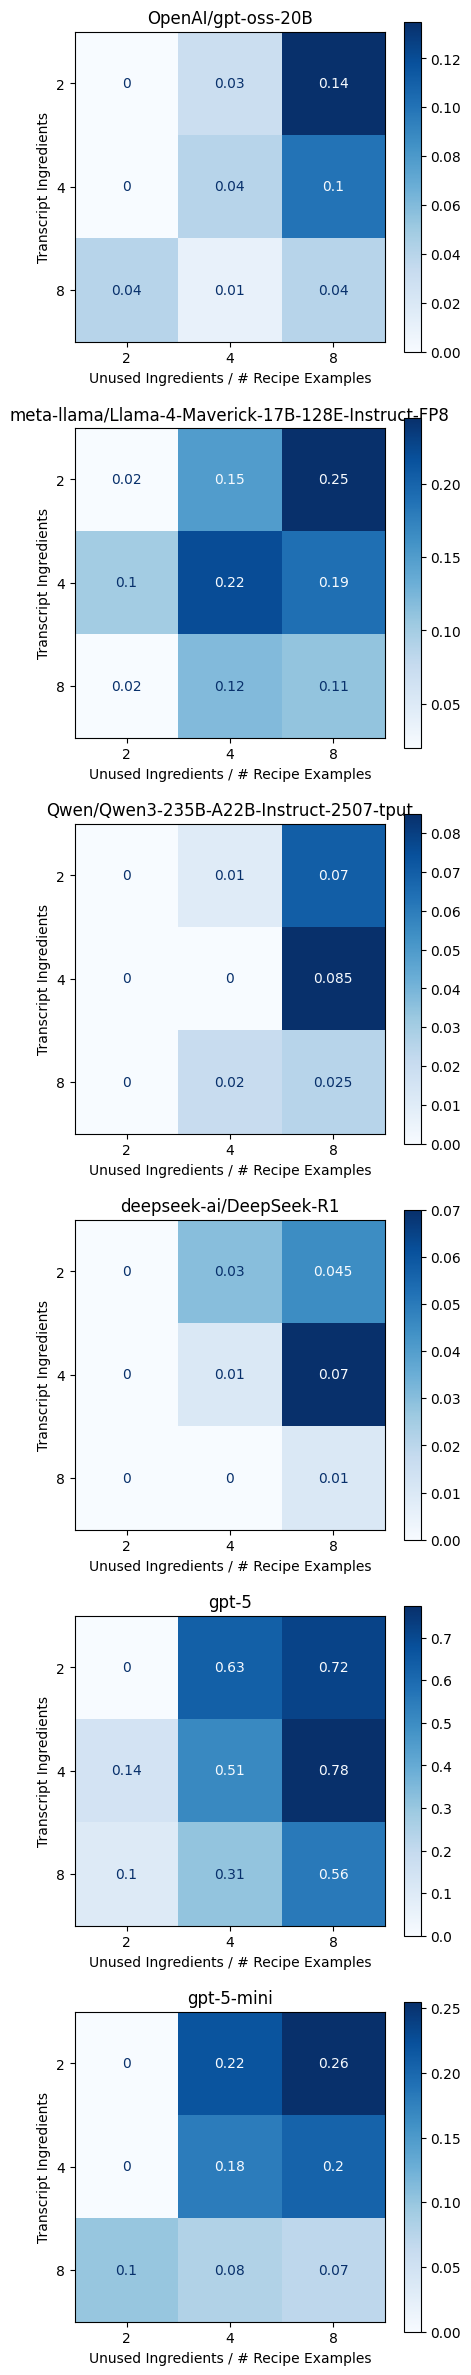

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

size = 5
fig, ax = plt.subplots(len(model_list), 1, figsize=(size, len(model_list)*size))
for i, model in enumerate(model_list):
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix_map[model],
                                  display_labels=[2,4,8])
    disp.plot(ax=ax[i], cmap='Blues')

    ax[i].set_title(model)
    ax[i].set_xlabel('Unused Ingredients / # Recipe Examples')
    ax[i].set_ylabel('Transcript Ingredients')


# Single Axis Tests

In [139]:
model_list = [
    "DeepSeek-R1",
    'gpt-5',
    'gpt-5-mini',
    "gpt-oss-20B",
    # 'Qwen3-235B-A22B-Instruct-2507-tput',
    'Llama-4-Maverick-17B-128E-Instruct-FP8'
]

In [147]:
import math

size = 5
# fig, ax = plt.subplots(len(model_list), 1, figsize=(size * 2, len(model_list)*size))
def plot_results(axis):
    fig, ax = plt.subplots(layout='constrained')

    for i, model in enumerate(model_list):
        t_ings = [file for file in os.listdir(f'results/{model}') if file.startswith(axis) and file.endswith('.csv')]
        bins = [2,4,8,16]
        result_bins = [0, 0.25, 0.5, 0.75, 1]
        # print(t_ings)

        means = []
        sds = []
        for j, bin in enumerate(bins):
            file = [file for file in t_ings if str(bin) in file][0]
            df = pd.read_csv(f'results/{model}/{file}')
            # print(df.head())
            overall_correct = []
            for ind, item in df['correct'].items():
                overall_correct.extend(eval(item))
            # print(overall_correct)
            mean = sum(overall_correct)/len(overall_correct)
            means.append(mean)
            sd = math.sqrt((mean * (1-mean)) / len(overall_correct))
            sds.append(sd)
            # print(df['overall_acc'])
            # ax[i].bar(x + width*j, freq, width, label=f'unused_ings={bin}')
            # ax[i].plot(x, norm.pdf(x, mean, sd), label=f'unused_ings={bin}')
        x = [x * 2 + i * (1/len(model_list)) for x in range(len(bins))]
        rects = ax.bar(x, means, width=(1/len(model_list)), edgecolor='black', label=f'{model}')
        # plt.bar_label(rects, label_type='edge', padding=3)
        ax.errorbar(x, means, yerr = sds, fmt ='o', color='black')
        # print(results)
        # ax.plot(bins, means, label=model)
        # ax.errorbar(bins, means, yerr=sds)
        # ax[i].set_title(model)
        # ax[i].legend()

    xticks = [f'{axis}: {b}' for b in bins]
    # print(xticks)
    ax.set_xticks([x * 2 + 0.3 for x in range(len(bins))], xticks, rotation=-30)
    ax.set_title(f'Overall Accuracy by {axis} Count')
    ax.set_ylim(0,1)
    ax.legend()
    plt.show()

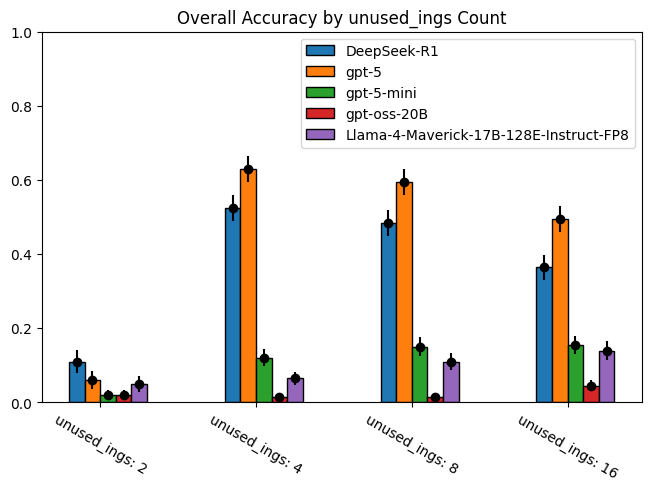

In [149]:
plot_results('unused_ings')

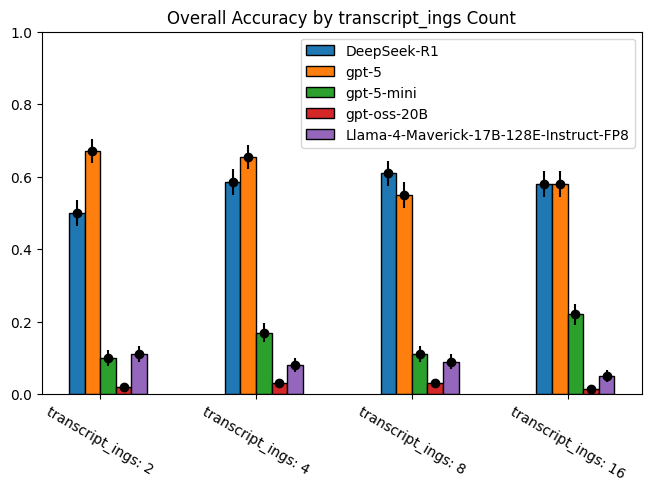

In [150]:
plot_results('transcript_ings')